## Tarea 1
Programa Experto en Inteligencia Artificial con Python  
ML3009 - Series de Tiempo  
Estudiante: Natalia Bonilla Villalobos.  
**Series de Tiempo**

<a id="menu"></a>

# Menú
- [Ejercicio 1](#ej1)
- [Ejercicio 2](#ej2)
- [Ejercicio 3](#ej3)
- [Ejercicio 4](#ej4)
- [Ejercicio 5](#ej5)
- [Ejercicio 6](#ej6)
- [Ejercicio 7](#ej7)

In [115]:
import warnings
import pandas as pd
import numpy as np
from random import sample
from datetime import date
from datetime import datetime
import locale
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from datetime import timedelta

warnings.filterwarnings('ignore')  # Oculta warnings en la salida

<a id="ej1"></a>
# Ejercicio 1 
[10 puntos] Explique por qué los datos de la tabla incluida en el archivo `OilPrice.csv` no son una serie de tiempo?

[↑ Volver al Menú](#menu)


In [2]:
oildf = pd.read_csv('OilPrice.csv', delimiter=';', decimal=',')

In [3]:
oildf[:10]

,Fecha,Precio
0,ene 02 1986,25.56
1,ene 03 1986,26.00
2,ene 06 1986,26.53
3,ene 07 1986,25.85
4,ene 08 1986,25.87
5,ene 09 1986,26.03
6,ene 10 1986,25.65
7,ene 13 1986,25.08
8,ene 14 1986,24.97
9,ene 15 1986,25.18


In [4]:
locale.setlocale(locale.LC_ALL, "es_ES")

'es_ES'

In [5]:
oildf.shape

(8157, 2)

In [6]:
df_oil = oildf.copy()

In [7]:
df_oil['Fecha'] = df_oil['Fecha'].str.replace(r'^(\w{3})', r'\1.', regex=True)
df_oil.sample(5)

,Fecha,Precio
6192,mar. 01 2010,78.71
4823,oct. 13 2004,53.86
1998,oct. 20 1993,18.25
1504,nov. 15 1991,22.79
2962,jul. 21 1997,19.25


In [8]:
for i in range(len(df_oil)):
    date = df_oil['Fecha'][i]
    # print(date)
    # if i == 10:
    #     break
    df_oil['Fecha'][i] = datetime.strptime(date, '%b %d %Y').date()

In [9]:
df_oil.head(5)

,Fecha,Precio
0,1986-01-02,25.56
1,1986-01-03,26.00
2,1986-01-06,26.53
3,1986-01-07,25.85
4,1986-01-08,25.87


In [10]:
start_date = df_oil['Fecha'].min()
print(start_date)
end_date = df_oil['Fecha'].max()
print(end_date)

1986-01-02
2017-11-20


In [11]:
fechas_test = pd.date_range(start = start_date, end = end_date, freq = 'D').tolist()
fechas_test[:10]

[Timestamp('1986-01-02 00:00:00'),
 Timestamp('1986-01-03 00:00:00'),
 Timestamp('1986-01-04 00:00:00'),
 Timestamp('1986-01-05 00:00:00'),
 Timestamp('1986-01-06 00:00:00'),
 Timestamp('1986-01-07 00:00:00'),
 Timestamp('1986-01-08 00:00:00'),
 Timestamp('1986-01-09 00:00:00'),
 Timestamp('1986-01-10 00:00:00'),
 Timestamp('1986-01-11 00:00:00')]

In [12]:
# faltan_fechas = [x for x in fechas_test if x not in df_oil.Fecha.to_list()]

# Una forma más sencilla de entender lo que hacer este for es verlo de la siguiente manera:
faltan_fechas = []
for x in fechas_test:
   if x not in df_oil.Fecha.to_list():
       faltan_fechas.append(x)

faltan_fechas[:10]

[Timestamp('1986-01-02 00:00:00'),
 Timestamp('1986-01-03 00:00:00'),
 Timestamp('1986-01-04 00:00:00'),
 Timestamp('1986-01-05 00:00:00'),
 Timestamp('1986-01-06 00:00:00'),
 Timestamp('1986-01-07 00:00:00'),
 Timestamp('1986-01-08 00:00:00'),
 Timestamp('1986-01-09 00:00:00'),
 Timestamp('1986-01-10 00:00:00'),
 Timestamp('1986-01-11 00:00:00')]

In [13]:
len(faltan_fechas)

11646

Los datos en `OilPrice.csv` no se considera una serie de tiempo porque tiene fechas faltantes y para que pueda ser una serie de tiempo debe de tener las fechas completas o dicho de otra forma debe de tener registros secuenciales.

<a id="ej1"></a>
# Ejercicio 2
[10 puntos] Guarde el siguiente texto en una variable 'Hora de Registro: 10:00. Del día martes 22 de abril del año 2025'. Convierta dicha variable a tipo `datetime` y luego muestre el resultado.


[↑ Volver al Menú](#menu)


In [14]:
registro = 'Hora de Registro: 10:00. Del día martes 22 de abril del año 2025'
registro = pd.to_datetime(registro, format='Hora de Registro: %H:%M. Del día %A %d de %B del año %Y')
registro

Timestamp('2025-04-22 10:00:00')

<a id="ej3"></a>
# Ejercicio 3 
[10 puntos] Calcule la diferencia en minutos, horas, días, semanas, meses y años entre las fechas 16/10/2020 y 14/03/2025.

[↑ Volver al Menú](#menu)

In [15]:
fecha_1 = '16/10/2020'
fecha_2 = '14/03/2025'
inicio = datetime.strptime(fecha_1, '%d/%m/%Y')
fin = datetime.strptime(fecha_2, '%d/%m/%Y')

diferencia = fin - inicio
minutos = diferencia / timedelta(minutes = 1)
horas = diferencia / timedelta(hours = 1)
dias = diferencia / timedelta(days = 1)
meses = round(dias / 30, 2)
years = round(dias / 365, 2)
print(f'La diferencia entre las fechas {fecha_1} y {fecha_2} es de: {minutos} minutos, {horas} horas, {dias} días, {meses} meses y {years} años')

La diferencia entre las fechas 16/10/2020 y 14/03/2025 es de: 2318400.0 minutos, 38640.0 horas, 1610.0 días, 53.67 meses y 4.41 años


<a id="ej4"></a>
# Ejercicio 4
[10 puntos] El archivo `emision_monetaria_CR.csv` que contiene la emisión monetaria del BCCR como saldos a fin de mes en millones de colones, desde enero de 1986 hasta marzo del 2026.  
Obtenga una serie de tiempo y grafique usando `plot` y `plotly`.

[↑ Volver al Menú](#menu)

In [16]:
moneda_cr = pd.read_csv('emision_monetaria_CR.csv')
moneda_cr

,Fecha,Valor
0,1986-01-01,12069.5
1,1986-02-01,12314.0
2,1986-03-01,12920.9
3,1986-04-01,12254.1
4,1986-05-01,12478.1
...,...,...
478,2025-11-01,1595905.1
479,2025-12-01,1625018.7
480,2026-01-01,1491267.8
481,2026-02-01,1471950.0


In [17]:
fechas = pd.DatetimeIndex(moneda_cr.Fecha, freq = 'MS') # Fechas mensuales (imprime el primer día del mes).
ts_moneda = pd.Series(moneda_cr.Valor.values, index = fechas)
ts_moneda

Fecha
1986-01-01      12069.5
1986-02-01      12314.0
1986-03-01      12920.9
1986-04-01      12254.1
1986-05-01      12478.1
                ...    
2025-11-01    1595905.1
2025-12-01    1625018.7
2026-01-01    1491267.8
2026-02-01    1471950.0
2026-03-01    1503491.6
Freq: MS, Length: 483, dtype: float64

## Gráfico con Plot

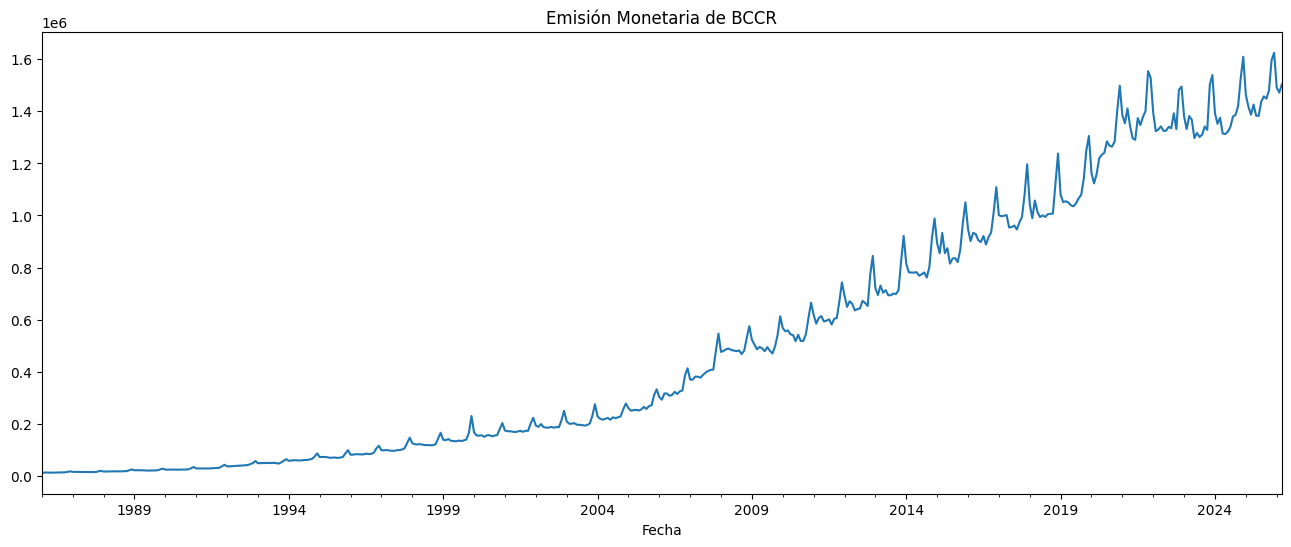

In [18]:
ts_moneda.plot(figsize=(16, 6), title='Emisión Monetaria de BCCR')
plt.show()

## Gráfico con Plotly

In [19]:
ts_moneda_df = ts_moneda.to_frame(name = "Valor")

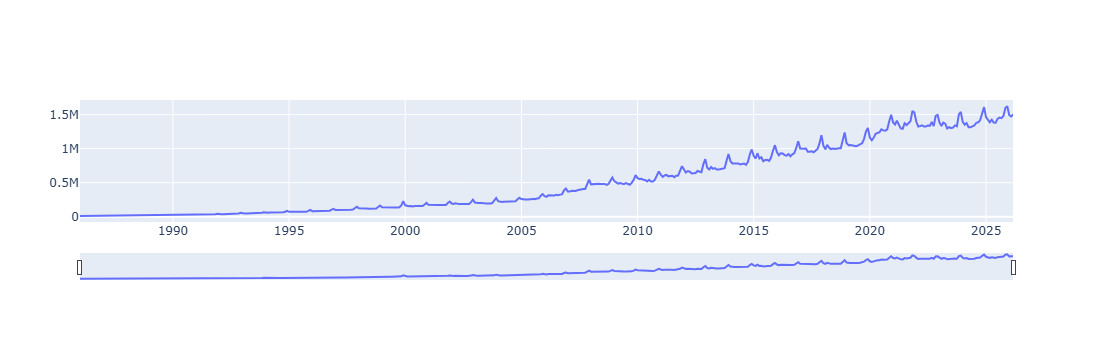

In [20]:
fig = go.Figure()
no_plot = fig.add_trace(
    go.Scatter(x = ts_moneda.index.tolist(), y = ts_moneda.values.tolist()) #, mode = 'lines+markers')
)

no_plot = fig.update_xaxes(rangeslider_visible=True)
fig.show()

<a id="ej5"></a>
# Ejercicio 5
[20 puntos] Para este ejercicio se deben usar los datos `velocidad_viento.csv`. La datos tratan sobre la medición de la velocidad del viento cada 10 minutos. Con la tabla realice lo siguiente:
- a) Cargue los datos. Despliegue en el documento un head de los resultados.
- b) Verifique si existen fechas faltantes. De ser así, impute dichas fechas y para cada variable asígnele su promedio.
- c) Convierta los datos a una serie de tiempo utilizado la variable `VelocidadViento` (Observe que la tabla de datos viene por cada 10 minutos). Despliegue en el documento un head de los resultados.


[↑ Volver al Menú](#menu)

## Parte 1
- a) Cargue los datos. Despliegue en el documento un head de los resultados.

In [65]:
viento_df = pd.read_csv('velocidad_viento.csv', delimiter=';', decimal=',')
viento_df

,Fecha,VelocidadViento
0,2020-01-01 06:00:00,5.4772348750000015
1,2020-01-01 06:10:00,6.362752373684209
2,2020-01-01 06:20:00,6.522534785
3,2020-01-01 06:30:00,5.636349794444443
4,2020-01-01 06:40:00,5.720647215789473
...,...,...
12741,2020-03-30 23:10:00,3.53344485
12742,2020-03-30 23:20:00,3.261231389473684
12743,2020-03-30 23:30:00,3.33183875
12744,2020-03-30 23:40:00,3.284468215789474


In [66]:
viento_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12746 entries, 0 to 12745
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Fecha            12746 non-null  object
 1   VelocidadViento  12746 non-null  object
dtypes: object(2)
memory usage: 199.3+ KB


In [133]:
velocidad_viento = viento_df.copy()

In [134]:
velocidad_viento['VelocidadViento'].isnull().sum()

np.int64(0)

In [135]:
velocidad_viento['Fecha'] = velocidad_viento['Fecha'].astype('datetime64[ns]')
velocidad_viento['VelocidadViento'] = velocidad_viento['VelocidadViento'].astype('float64')
velocidad_viento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12746 entries, 0 to 12745
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Fecha            12746 non-null  datetime64[ns]
 1   VelocidadViento  12746 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 199.3 KB


In [136]:
prom_velocidad = velocidad_viento['VelocidadViento'].mean()
prom_velocidad

np.float64(5.395824636338451)

## Parte 2
- b) Verifique si existen fechas faltantes. De ser así, impute dichas fechas y para cada variable asígnele su promedio.

In [137]:
start_fecha = velocidad_viento['Fecha'].min()
print(start_fecha)
end_fecha = velocidad_viento['Fecha'].max() # end_fecha  = velocidad_viento.Fecha.to_list()[len(velocidad_viento.Fecha.to_list()) - 1] # Recuerde que en python se empieza en 0, por esto restamos 1
print(end_fecha)

2020-01-01 06:00:00
2020-03-30 23:50:00


In [138]:
new_dates = pd.date_range(start = start_fecha, end = end_fecha, freq = '10T').tolist()
print('cantidad de fechas:', len(new_dates))

cantidad de fechas: 12924


In [139]:
print('Diferencia en el número de filas:', len(velocidad_viento) - len(new_dates))

Diferencia en el número de filas: -178


In [140]:
new_dates[:1] == velocidad_viento['Fecha'][:1]

0    True
Name: Fecha, dtype: bool

In [141]:
faltan_fechas = [x for x in new_dates if x not in velocidad_viento.Fecha.to_list()]

# Una forma más sencilla de entender lo que hacer este for es verlo de la siguiente manera:
# faltan_fechas = []
# for x in new_dates:
#    if x not in velocidad_viento.Fecha.to_list():
#        faltan_fechas.append(x)

faltan_fechas[:10]

[Timestamp('2020-01-03 11:20:00'),
 Timestamp('2020-01-03 11:30:00'),
 Timestamp('2020-01-03 11:40:00'),
 Timestamp('2020-01-03 11:50:00'),
 Timestamp('2020-01-03 12:00:00'),
 Timestamp('2020-01-03 12:10:00'),
 Timestamp('2020-01-03 12:20:00'),
 Timestamp('2020-01-03 12:30:00'),
 Timestamp('2020-01-03 12:40:00'),
 Timestamp('2020-01-06 06:40:00')]

In [142]:
print('cantidad:', len(velocidad_viento))

cantidad: 12746


In [143]:
df_vviento = pd.concat([velocidad_viento, pd.DataFrame({'Fecha': faltan_fechas})], ignore_index = True) # Se añaden las fechas faltantes al final 

df_vviento.sort_values(by = 'Fecha', inplace = True) # Se ordenan las fechas de forma ascendente
df_vviento

,Fecha,VelocidadViento
0,2020-01-01 06:00:00,5.477235
1,2020-01-01 06:10:00,6.362752
2,2020-01-01 06:20:00,6.522535
3,2020-01-01 06:30:00,5.636350
4,2020-01-01 06:40:00,5.720647
...,...,...
12741,2020-03-30 23:10:00,3.533445
12742,2020-03-30 23:20:00,3.261231
12743,2020-03-30 23:30:00,3.331839
12744,2020-03-30 23:40:00,3.284468


In [144]:
df_vviento.isna().sum()

Fecha                0
VelocidadViento    178
dtype: int64

In [145]:
df_vviento.loc[df_vviento['VelocidadViento'].isna(), 'VelocidadViento'] = prom_velocidad

In [146]:
df_vviento.isna().sum()

Fecha              0
VelocidadViento    0
dtype: int64

## Parte 3
- c) Convierta los datos a una serie de tiempo utilizado la variable `VelocidadViento` (Observe que la tabla de datos viene por cada 10 minutos). Despliegue en el documento un head de los resultados.

In [ ]:
serie_viento = df_vviento['VelocidadViento']
serie_viento = serie_viento.asfreq('10T') # frecuencia c/10min
serie_viento.head()

Fecha
2020-01-01 06:00:00    5.477235
2020-01-01 06:10:00    6.362752
2020-01-01 06:20:00    6.522535
2020-01-01 06:30:00    5.636350
2020-01-01 06:40:00    5.720647
Freq: 10min, Name: VelocidadViento, dtype: float64

<a id="ej6"></a>
# Ejercicio 6
[20 puntos] Utilizando la serie de tiempo obtenida en el punto anterior realice lo siguiente:
- a) Transforme la serie de datos por cada 10 minutos en una serie de datos sumados por hora y convierta a serie de tiempo. Despliegue en el documento un head de los resultados.
- b) Transforme la serie de datos por cada 10 minutos en una serie de datos sumados por día y convierta a serie de tiempo. Despliegue en el documento un head de los resultados.
- c) Transforme la serie de datos por cada 10 minutos en una serie de datos promediados por día y convierta a serie de tiempo. Despliegue en el documento un head de los resultados.

[↑ Volver al Menú](#menu)

In [ ]:
# a) Transforme la serie de datos por cada 10 minutos en una serie de datos sumados por hora y convierta a serie de tiempo. Despliegue en el documento un head de los resultados.
serie_hora = serie_viento.resample('H').sum()
serie_hora.head()

Fecha
2020-01-01 06:00:00    35.378664
2020-01-01 07:00:00    35.083605
2020-01-01 08:00:00    32.666084
2020-01-01 09:00:00    30.659121
2020-01-01 10:00:00    32.522158
Freq: h, Name: VelocidadViento, dtype: float64

In [ ]:
# b) Transforme la serie de datos por cada 10 minutos en una serie de datos sumados por día y convierta a serie de tiempo. Despliegue en el documento un head de los resultados.
serie_dia = serie_viento.resample('D').sum()
serie_dia.head()

Fecha
2020-01-01    720.345901
2020-01-02    755.605188
2020-01-03    619.676491
2020-01-04    628.743139
2020-01-05    898.579001
Freq: D, Name: VelocidadViento, dtype: float64

In [ ]:
# c) Transforme la serie de datos por cada 10 minutos en una serie de datos promediados por día y convierta a serie de tiempo. Despliegue en el documento un head de los resultados.
serie_dia_mean = serie_viento.resample('D').mean()
serie_dia_mean.head()

Fecha
2020-01-01    6.669869
2020-01-02    5.247258
2020-01-03    4.303309
2020-01-04    4.366272
2020-01-05    6.240132
Freq: D, Name: VelocidadViento, dtype: float64

<a id="ej7"></a>
# Ejercicio 7
[20 puntos] La tabla `BTC_USD_2023.csv` contiene el valor del Bitcoin con respecto al dólar desde el 04 de enero del 2021 al 30 de setiembre del 2023. Con la tabla realice lo siguiente:  
- a) Verifique si existen fechas faltantes. De ser así, impute dichas fechas y para cada variable asígnele su promedio.
- b) Convierta los datos a una serie de tiempo utilizado la variable Close. Despliegue en el documento un head de los resultados.
- c) Grafique la serie de tiempo.

**NOTA: Toda conversión a serie de tiempo debe incluir la frecuencia correspondiente.**


[↑ Volver al Menú](#menu)

## Parte 1

- a) Verifique si existen fechas faltantes. De ser así, impute dichas fechas y para cada variable asígnele su promedio.

In [169]:
df_bitcoin = pd.read_csv('BTC_USD_2023.csv')
df_bitcoin

,Date,Open,High,Low,Close,Adj Close,Volume
0,2021-01-04,32810.949219,33440.218750,28722.755859,31971.914063,31971.914063,81163475344
1,2021-01-05,31977.041016,34437.589844,30221.187500,33992.429688,33992.429688,67547324782
2,2021-01-06,34013.613281,36879.699219,33514.035156,36824.363281,36824.363281,75289433811
3,2021-01-07,36833.875000,40180.367188,36491.191406,39371.042969,39371.042969,84762141031
4,2021-01-08,39381.765625,41946.738281,36838.636719,40797.609375,40797.609375,88107519480
...,...,...,...,...,...,...,...
995,2023-09-26,26294.757813,26389.884766,26090.712891,26217.250000,26217.250000,9985498161
996,2023-09-27,26209.498047,26817.841797,26111.464844,26352.716797,26352.716797,11718380997
997,2023-09-28,26355.812500,27259.500000,26327.322266,27021.546875,27021.546875,14079002707
998,2023-09-29,27024.841797,27225.937500,26721.763672,26911.720703,26911.720703,10396435377


In [180]:
df_bitcoin['Date'] = df_bitcoin['Date'].astype('datetime64[ns]')
df_bitcoin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1000 non-null   datetime64[ns]
 1   Open       1000 non-null   float64       
 2   High       1000 non-null   float64       
 3   Low        1000 non-null   float64       
 4   Close      1000 non-null   float64       
 5   Adj Close  1000 non-null   float64       
 6   Volume     1000 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 54.8 KB


In [181]:
start_date = df_bitcoin['Date'].min().date()
print(start_date)
end_date = df_bitcoin['Date'].max().date()
print(end_date)

2021-01-04
2023-09-30


In [182]:
compare_dates = pd.date_range(start = start_date, end = end_date, freq = 'D').tolist()
print('cantidad de fechas:', len(compare_dates))

cantidad de fechas: 1000


No hay fechas faltantes, por lo que no se imputan datos

## Parte 2
- b) Convierta los datos a una serie de tiempo utilizado la variable Close. Despliegue en el documento un head de los resultados.
- c) Grafique la serie de tiempo.

In [191]:
dates = pd.DatetimeIndex(df_bitcoin.Date, freq = 'D') 
close_btc = pd.Series(df_bitcoin.Close.values, index = dates)
close_btc


Date
2021-01-04    31971.914063
2021-01-05    33992.429688
2021-01-06    36824.363281
2021-01-07    39371.042969
2021-01-08    40797.609375
                  ...     
2023-09-26    26217.250000
2023-09-27    26352.716797
2023-09-28    27021.546875
2023-09-29    26911.720703
2023-09-30    26967.916016
Freq: D, Length: 1000, dtype: float64

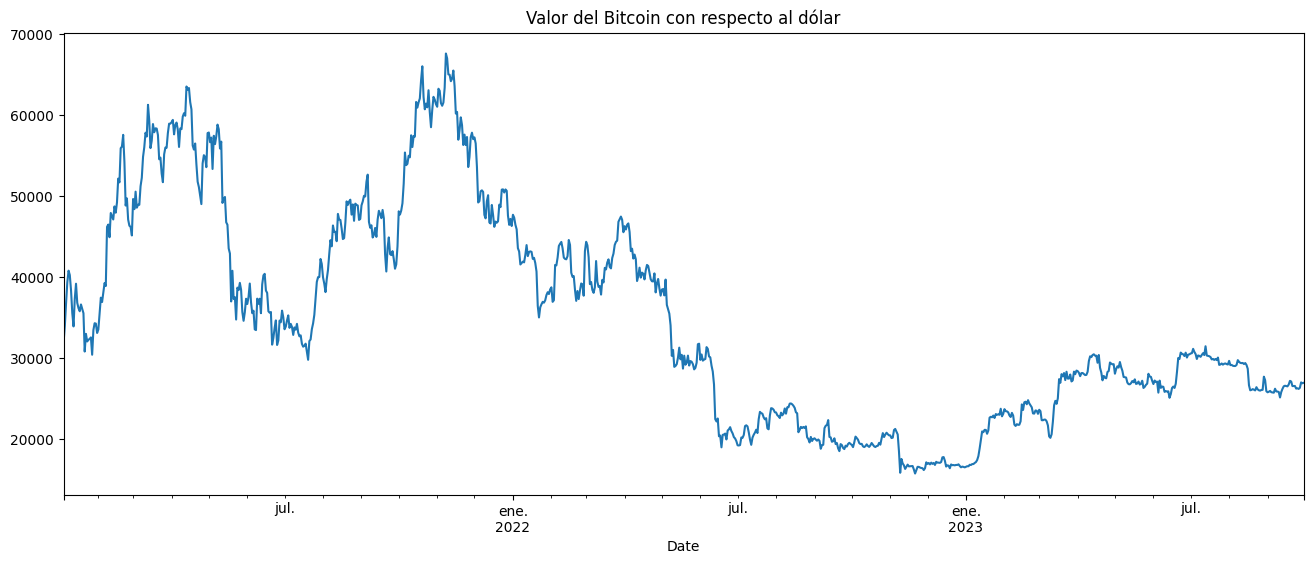

In [193]:
close_btc.plot(figsize=(16, 6), title='Valor del Bitcoin con respecto al dólar')
plt.show()

In [195]:
close_btc_df = close_btc.to_frame(name = "Close")

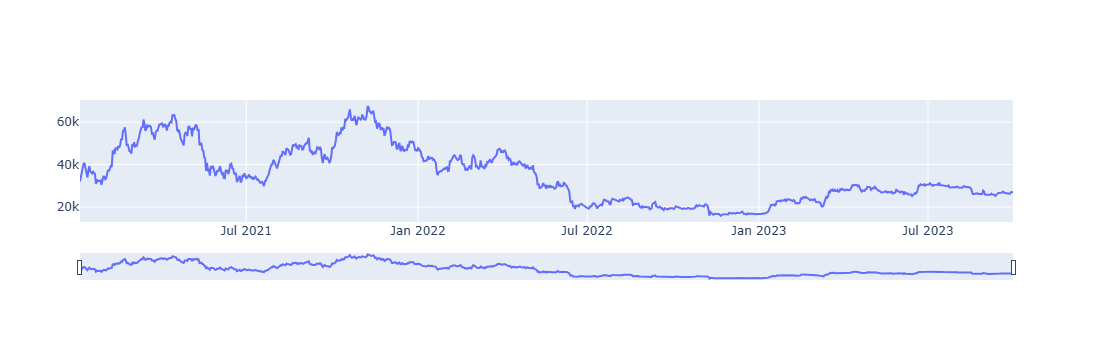

In [196]:
fig = go.Figure()
no_plot = fig.add_trace(
    go.Scatter(x = close_btc.index.tolist(), y = close_btc.values.tolist()) #, mode = 'lines+markers')
)

no_plot = fig.update_xaxes(rangeslider_visible=True)
fig.show()